## KuaiRec

중국 숏폼 영상 앱 쾌수(Kuaishou) 의 실제 추천 로그를 수집한 데이터셋

KuaiRec/data/

├── small_matrix.csv      ← 완전관측 행렬 (밀도 99.6%)

├── big_matrix.csv        ← 일반 추천 로그 (희소)

├── user_features.csv     ← 유저 특성 (56개 feature)

├── item_categories.csv   ← 아이템 카테고리

├── item_daily_features.csv ← 아이템 일별 특성

└── social_network.csv    ← 유저 소셜 네트워크

https://github.com/chongminggao/KuaiRec

| 항목 | small_matrix | big_matrix |
| --- | --- | --- |
| 설명 | 일부 유저에게 의도적으로 거의 모든 영상을 노출시켜 수집한 데이터 | Kuaishou의 실제 추천 시스템이 작동한 데이터 |
| 특징 | 거의 모든 (user, item) 쌍에 대해 watch_ratio가 존재 | 편향됨 |
| 밀도 | **99.6%** | 희소 |
| 유저 수 | 1,411명 | 7,176명 |
| 아이템 수 | 3,327개 | 3,327개 |
| 행 수 | 487,819행 | 약 1,200만 행 |
| 용도 | IPW 계산 + 평가 | 모델 학습 |


[Step 1] big_matrix에서 편향 측정 + 시각화

[Step 2] small_matrix에서 propensity 추정

[Step 3] big_matrix로 모델 학습

[Step 4] small_matrix로 평가

### 핵심 변수 — watch_ratio

watch_ratio = play_duration / video_duration

- 0.0 ~ 1.0: 부분 시청
- 1.0 이상:  반복 시청 (강한 선호)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

big = pd.read_csv("KuaiRec/data/big_matrix.csv")
small = pd.read_csv("KuaiRec/data/small_matrix.csv")

print(f"big_matrix:   {len(big):>12,} rows, "
      f"{big['user_id'].nunique():>5,} users, "
      f"{big['video_id'].nunique():>6,} items")
print(f"small_matrix: {len(small):>12,} rows, "
      f"{small['user_id'].nunique():>5,} users, "
      f"{small['video_id'].nunique():>6,} items")

big_matrix:     12,530,806 rows, 7,176 users, 10,728 items
small_matrix:    4,676,570 rows, 1,411 users,  3,327 items


## 1단계 — 편향 측정
목표: "big_matrix가 얼마나 노출 편향되어 있는가"를 정량화.

(a) 아이템 노출 빈도의 long-tail 분포

상위 10% 아이템이 전체 노출의 40.7% 차지


Text(0.5, 1.0, 'Long-tail exposure distribution')

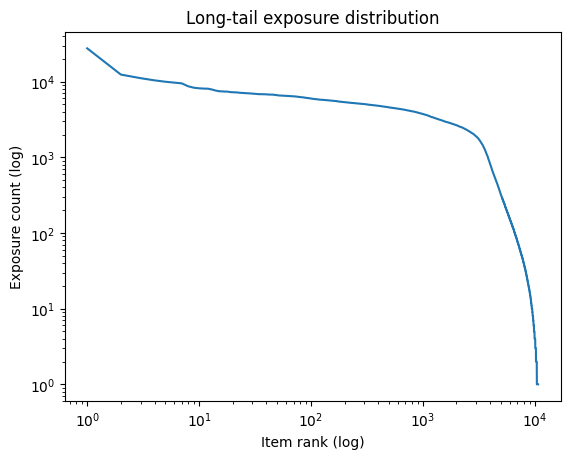

In [16]:
item_exposure = big.groupby("video_id").size().sort_values(ascending=False)

# 누적 점유율
cum_share = item_exposure.cumsum() / item_exposure.sum()
top_10pct_idx = int(len(item_exposure) * 0.1)
print(f"상위 10% 아이템이 전체 노출의 {cum_share.iloc[top_10pct_idx]*100:.1f}% 차지")

# 로그-로그 plot
plt.loglog(np.arange(1, len(item_exposure)+1), item_exposure.values)
plt.xlabel("Item rank (log)")
plt.ylabel("Exposure count (log)")
plt.title("Long-tail exposure distribution")

(b) Gini 계수 - 노출 불평등 정량화 (0.7 이상이면 심한 편향)

In [17]:
def gini(x):
    x = np.sort(np.array(x, dtype=float))
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1)) * x) - (n+1) * x.sum()) / (n * x.sum())

print(f"Item exposure Gini: {gini(item_exposure.values):.3f}")

Item exposure Gini: 0.672


(c) watch_ratio vs 노출 빈도의 관계

노출 분위가 높을수록 평균 watch_ratio도 높음 → 편향과 선호가 얽혀 있다

In [18]:
item_stats = big.groupby("video_id").agg(
    exposure=("watch_ratio", "size"),
    mean_wr=("watch_ratio", "mean"),
    median_wr=("watch_ratio", "median"),
).reset_index()

# 노출 빈도 분위로 묶어서 평균 watch_ratio 비교
item_stats["exposure_bin"] = pd.qcut(item_stats["exposure"], 10, labels=False)
print(item_stats.groupby("exposure_bin")["mean_wr"].mean())

exposure_bin
0    2.600338
1    1.300804
2    1.205488
3    1.065947
4    1.009756
5    0.969871
6    0.957789
7    0.941404
8    0.952266
9    0.927667
Name: mean_wr, dtype: float64


## 2단계 — Propensity Score 계산

Item-based propensity

$$P(O=1 \mid i) = \frac{\text{\# of exposures of } i}{\text{\# of users}}$$

In [19]:
# 각 아이템이 노출된 unique 유저 수
exposure_count = big.groupby("video_id")["user_id"].nunique()
n_users_big = big["user_id"].nunique()

# Propensity 추정
propensity = exposure_count / n_users_big

print("=== Raw propensity 분포 ===")
print(propensity.describe())
print(f"\n중앙값: {propensity.median():.4f}")
print(f"최솟값: {propensity.min():.4f}")
print(f"최댓값: {propensity.max():.4f}")

=== Raw propensity 분포 ===
count    10728.000000
mean         0.133806
std          0.172113
min          0.000139
25%          0.004738
50%          0.030588
75%          0.259511
max          0.747910
Name: user_id, dtype: float64

중앙값: 0.0306
최솟값: 0.0001
최댓값: 0.7479


Clipping — 분산 안정화

propensity가 너무 작을 때 가중치 1/P가 폭발하는 것을 방지하기 위해 하한선을 설정

In [27]:
# Clipping (하한 0.01)
PROPENSITY_FLOOR = 0.05
propensity_clipped = propensity.clip(lower=PROPENSITY_FLOOR, upper=1.0)

print(f"=== Clipping 효과 ===")
print(f"Clipping 전 최솟값: {propensity.min():.5f}")
print(f"Clipping 후 최솟값: {propensity_clipped.min():.5f}")
print(f"Clipping된 아이템 수: {(propensity < PROPENSITY_FLOOR).sum()}/{len(propensity)}")

=== Clipping 효과 ===
Clipping 전 최솟값: 0.00014
Clipping 후 최솟값: 0.05000
Clipping된 아이템 수: 5980/10728


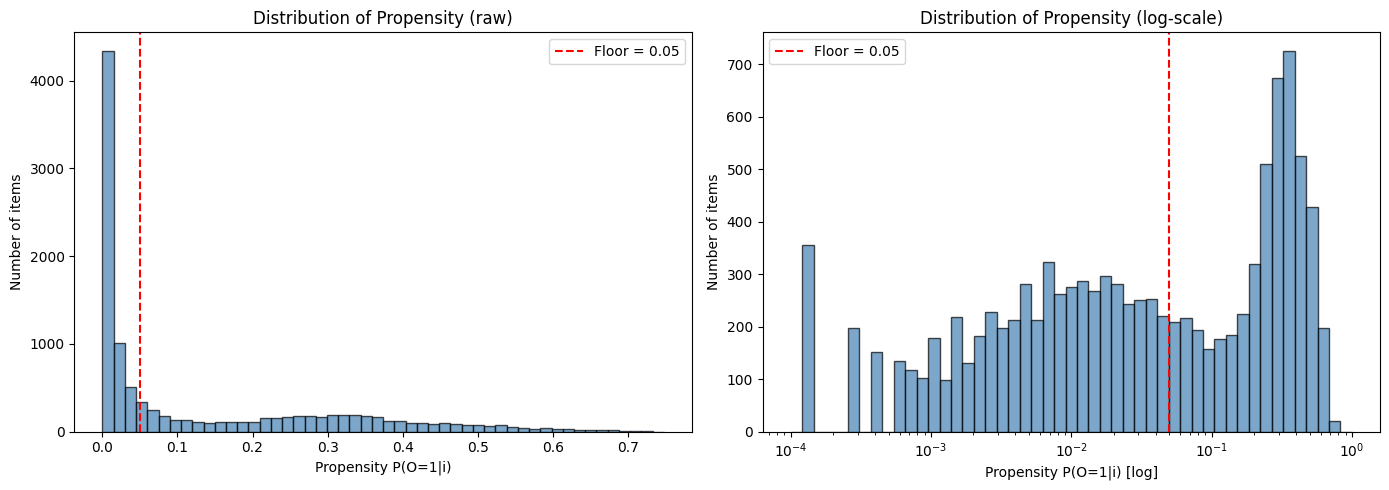

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Raw propensity
axes[0].hist(propensity, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(PROPENSITY_FLOOR, color='red', linestyle='--', 
                label=f'Floor = {PROPENSITY_FLOOR}')
axes[0].set_xlabel("Propensity P(O=1|i)")
axes[0].set_ylabel("Number of items")
axes[0].set_title("Distribution of Propensity (raw)")
axes[0].legend()

# (b) Log-scale로
axes[1].hist(propensity, bins=np.logspace(-4, 0, 50), 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(PROPENSITY_FLOOR, color='red', linestyle='--',
                label=f'Floor = {PROPENSITY_FLOOR}')
axes[1].set_xscale('log')
axes[1].set_xlabel("Propensity P(O=1|i) [log]")
axes[1].set_ylabel("Number of items")
axes[1].set_title("Distribution of Propensity (log-scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

Big_matrix에 Propensity와 IPS Weight 매핑

In [30]:
# Propensity를 dataframe으로 변환
prop_df = propensity_clipped.rename("propensity").reset_index()

# big_matrix에 merge
big = big.merge(prop_df, on="video_id", how="left")

# IPS weight 계산
big["ips_weight"] = 1.0 / big["propensity"]

print("=== IPS Weight 분포 ===")
print(big["ips_weight"].describe())
print(f"\n최댓값: {big['ips_weight'].max():.2f}")
print(f"평균: {big['ips_weight'].mean():.2f}")

=== IPS Weight 분포 ===
count    1.253081e+07
mean     4.066590e+00
std      4.131255e+00
min      1.337060e+00
25%      2.090300e+00
50%      2.760000e+00
75%      3.768908e+00
max      2.000000e+01
Name: ips_weight, dtype: float64

최댓값: 20.00
평균: 4.07


IPS: Inverse Propensity Scoring

$$\hat Y_{IPS}(u,i)=\frac{O(u,i​) \cdot Y(u,i)}{P(O=1|u,i)}$$

unbiased를 만들려면 노출 안 된 쌍은 0, 노출된 쌍은 1/P로 가중 → 한 쌍의 잠재 결과를 개별적으로 복원

**구하고자 하는 것**

모델 $\pi_{\text{new}}$의 정책 가치 $V(\pi_{\text{new}})$

$$
\hat{V}_{\text{IPS}}(\pi_{\text{new}}) = \frac{1}{N} \sum_{(u,i) \in \mathcal{D}_{\log}} \frac{\pi_{\text{new}}(i \mid u)}{P(O=1 \mid u, i)} \cdot Y(u, i)
$$

"내 모델 $\pi_{\text{new}}$를 실제 사용했다면 평균 watch_ratio가 얼마나 나올까?"

정책 간 ATE

$$
\Delta V = V(\pi_{\text{new}}) - V(\pi_{\text{baseline}})
$$

IPS weight 분포

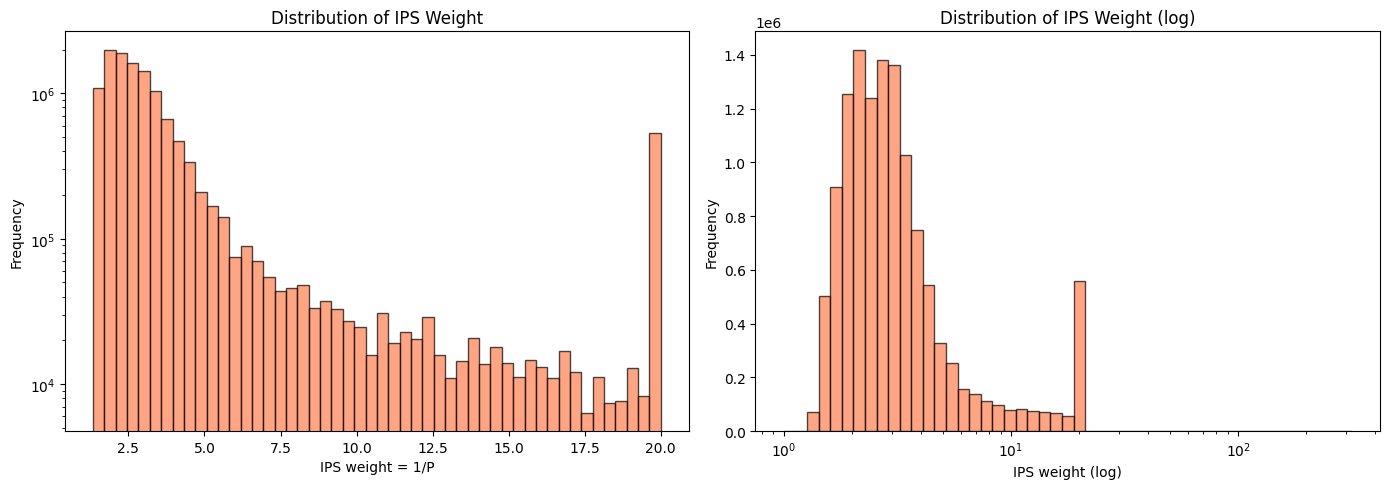

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) IPS weight 히스토그램
axes[0].hist(big["ips_weight"], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("IPS weight = 1/P")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of IPS Weight")
axes[0].set_yscale('log')

# (b) Log-scale
axes[1].hist(big["ips_weight"], bins=np.logspace(0, 2.5, 50), 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_xlabel("IPS weight (log)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of IPS Weight (log)")

plt.tight_layout()
plt.show()

Effective Sample Size (ESS) - IPS의 분산 폭발을 진단하는 표준 지표

In [32]:
weights = big["ips_weight"].values
ess = (weights.sum())**2 / (weights**2).sum()
ess_ratio = ess / len(weights)

print(f"=== Effective Sample Size ===")
print(f"원본 N:  {len(weights):,}")
print(f"ESS:     {ess:,.0f}")
print(f"비율:    {ess_ratio*100:.1f}%")

=== Effective Sample Size ===
원본 N:  12,530,806
ESS:     6,166,566
비율:    49.2%


## 3단계 — Baseline BPR vs IPS dibiased 모델 비교

In [33]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
import time

# 시드 고정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# 데이터 로드
big = pd.read_csv("KuaiRec/data/big_matrix.csv")
small = pd.read_csv("KuaiRec/data/small_matrix.csv")
print(f"big: {len(big):,} rows | small: {len(small):,} rows")

Device: cpu
big: 12,530,806 rows | small: 4,676,570 rows


### Positive 정의 + ID 매핑

watch_ratio >= 2.0 (반복 시청 = 강한 선호 신호)

In [34]:
# Positive: watch_ratio >= 2.0 (반복 시청)
WATCH_THRESHOLD = 2.0

big["positive"] = (big["watch_ratio"] >= WATCH_THRESHOLD).astype(int)
small["positive"] = (small["watch_ratio"] >= WATCH_THRESHOLD).astype(int)

print(f"=== Positive 비율 ===")
print(f"big:   {big['positive'].mean()*100:.1f}%  ({big['positive'].sum():,}개)")
print(f"small: {small['positive'].mean()*100:.1f}%  ({small['positive'].sum():,}개)")

# 학습은 positive 샘플만 사용 (BPR 표준)
train_pos = big[big["positive"] == 1].copy()
print(f"\n학습용 positive interaction: {len(train_pos):,}")

# user/item ID를 0부터 시작하는 연속 정수로 매핑
all_users = sorted(set(big["user_id"]) | set(small["user_id"]))
all_items = sorted(set(big["video_id"]) | set(small["video_id"]))

user2idx = {u: i for i, u in enumerate(all_users)}
item2idx = {v: i for i, v in enumerate(all_items)}

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)
print(f"\nN users: {N_USERS:,} | N items: {N_ITEMS:,}")

# 매핑 적용
train_pos["u_idx"] = train_pos["user_id"].map(user2idx)
train_pos["i_idx"] = train_pos["video_id"].map(item2idx)

small["u_idx"] = small["user_id"].map(user2idx)
small["i_idx"] = small["video_id"].map(item2idx)

=== Positive 비율 ===
big:   7.5%  (936,568개)
small: 4.6%  (217,229개)

학습용 positive interaction: 936,568

N users: 7,176 | N items: 10,728


### Propensity 매핑

In [35]:
# 2단계에서 만든 propensity를 item index 기준으로 변환
exposure_count = big.groupby("video_id")["user_id"].nunique()
n_users_big = big["user_id"].nunique()
propensity = exposure_count / n_users_big
propensity = propensity.clip(lower=0.05, upper=1.0)

# item_idx -> propensity 배열 (없는 아이템은 평균값으로)
mean_prop = propensity.mean()
propensity_arr = np.full(N_ITEMS, mean_prop, dtype=np.float32)
for video_id, p in propensity.items():
    if video_id in item2idx:
        propensity_arr[item2idx[video_id]] = p

# IPS weight = 1/P
ips_weight_arr = 1.0 / propensity_arr

print(f"Propensity 평균: {propensity_arr.mean():.3f}")
print(f"IPS weight 범위: [{ips_weight_arr.min():.2f}, {ips_weight_arr.max():.2f}]")

Propensity 평균: 0.156
IPS weight 범위: [1.34, 20.00]


### Positive set (negative sampling 용)

In [36]:
# 각 유저가 positive로 본 아이템 set (negative 샘플링 시 제외용)
user_pos_items = defaultdict(set)
for u, i in zip(train_pos["u_idx"].values, train_pos["i_idx"].values):
    user_pos_items[u].add(i)

print(f"평균 positive 수/유저: {np.mean([len(s) for s in user_pos_items.values()]):.1f}")

평균 positive 수/유저: 118.0


### BPR Model

In [38]:
class BPRDataset(Dataset):
    """매 epoch마다 (u, i+, i-) 트리플을 샘플링"""
    
    def __init__(self, train_df, user_pos_items, n_items, ips_weight_arr=None):
        self.users = train_df["u_idx"].values
        self.pos_items = train_df["i_idx"].values
        self.user_pos_items = user_pos_items
        self.n_items = n_items
        self.ips_weight = ips_weight_arr  # None이면 baseline, 있으면 IPS-BPR
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        u = self.users[idx]
        i_pos = self.pos_items[idx]
        
        # Negative 샘플링: positive set에 없을 때까지 random
        while True:
            i_neg = np.random.randint(0, self.n_items)
            if i_neg not in self.user_pos_items[u]:
                break
        
        if self.ips_weight is not None:
            w = self.ips_weight[i_pos]  # positive 아이템의 IPS weight
            return u, i_pos, i_neg, w
        else:
            return u, i_pos, i_neg, 1.0  # baseline은 weight=1
        

class BPR(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embedding_dim)
        self.item_emb = nn.Embedding(n_items, embedding_dim)
        
        # Initialization
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
    
    def forward(self, u, i_pos, i_neg):
        u_e = self.user_emb(u)
        i_pos_e = self.item_emb(i_pos)
        i_neg_e = self.item_emb(i_neg)
        
        score_pos = (u_e * i_pos_e).sum(dim=1)
        score_neg = (u_e * i_neg_e).sum(dim=1)
        
        return score_pos, score_neg
    
    def predict_all(self, u):
        """유저 u에 대한 모든 아이템 점수 (평가용)"""
        u_e = self.user_emb(u)  # (batch, dim)
        all_items_e = self.item_emb.weight  # (n_items, dim)
        scores = u_e @ all_items_e.T  # (batch, n_items)
        return scores

### Training 함수

In [39]:
def train_bpr(model, dataset, n_epochs=10, batch_size=2048, lr=1e-3, 
              reg=1e-5, use_ips=False, verbose=True):
    """BPR 또는 IPS-BPR 학습"""
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=reg)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, 
                        num_workers=0)  # CPU에서는 num_workers=0이 안전
    
    losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        start = time.time()
        
        for batch in loader:
            u, i_pos, i_neg, w = batch
            u = u.long().to(DEVICE)
            i_pos = i_pos.long().to(DEVICE)
            i_neg = i_neg.long().to(DEVICE)
            w = w.float().to(DEVICE)
            
            score_pos, score_neg = model(u, i_pos, i_neg)
            
            # BPR loss: -log sigmoid(s+ - s-)
            loss_per_sample = -F.logsigmoid(score_pos - score_neg)
            
            if use_ips:
                # IPS 가중 평균
                loss = (loss_per_sample * w).mean()
            else:
                loss = loss_per_sample.mean()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        elapsed = time.time() - start
        
        if verbose:
            tag = "IPS-BPR" if use_ips else "BPR    "
            print(f"  [{tag}] Epoch {epoch+1:2d}/{n_epochs} | "
                  f"loss={avg_loss:.4f} | {elapsed:.1f}s")
    
    return losses

### Evaluating 함수

In [40]:
def evaluate(model, eval_df, user_pos_items_train, K=10, batch_size=256):
    """small_matrix로 평가: Precision@K, Recall@K, NDCG@K, Coverage@K"""
    
    model.eval()
    
    # eval_df에서 각 유저의 positive 아이템 set 만들기
    user_pos_eval = defaultdict(set)
    for u, i, pos in zip(eval_df["u_idx"].values, 
                          eval_df["i_idx"].values,
                          eval_df["positive"].values):
        if pos == 1:
            user_pos_eval[u].add(i)
    
    eval_users = [u for u, items in user_pos_eval.items() if len(items) > 0]
    
    if len(eval_users) == 0:
        print("평가할 유저가 없습니다.")
        return {}
    
    precisions, recalls, ndcgs = [], [], []
    recommended_items = set()  # Coverage 계산용
    
    with torch.no_grad():
        for start in range(0, len(eval_users), batch_size):
            batch_users = eval_users[start:start+batch_size]
            u_tensor = torch.tensor(batch_users, dtype=torch.long, device=DEVICE)
            
            scores = model.predict_all(u_tensor)  # (batch, n_items)
            
            # 학습에서 본 positive는 추천 후보에서 제외 (mask)
            for idx, u in enumerate(batch_users):
                if u in user_pos_items_train:
                    seen = list(user_pos_items_train[u])
                    if seen:
                        scores[idx, seen] = -float('inf')
            
            # Top-K 추천
            _, topk = torch.topk(scores, K, dim=1)
            topk = topk.cpu().numpy()
            
            for idx, u in enumerate(batch_users):
                rec = topk[idx]
                gt = user_pos_eval[u]
                
                hits = [1 if item in gt else 0 for item in rec]
                n_hit = sum(hits)
                
                # Precision@K
                precisions.append(n_hit / K)
                
                # Recall@K
                recalls.append(n_hit / len(gt) if len(gt) > 0 else 0)
                
                # NDCG@K
                dcg = sum(h / np.log2(rank + 2) for rank, h in enumerate(hits))
                ideal_hits = min(len(gt), K)
                idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
                ndcgs.append(dcg / idcg if idcg > 0 else 0)
                
                # Coverage 누적
                recommended_items.update(rec.tolist())
    
    coverage = len(recommended_items) / N_ITEMS
    
    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "NDCG@K": np.mean(ndcgs),
        "Coverage@K": coverage,
        "n_eval_users": len(eval_users),
        "n_unique_recs": len(recommended_items),
    }

### Tail Recall
cold item 발굴 능력

In [41]:
def evaluate_tail(model, eval_df, user_pos_items_train, propensity_arr, 
                  K=10, tail_quantile=0.5, batch_size=256):
    """Cold/tail 아이템(propensity 하위 50%)에 대한 Recall@K"""
    
    model.eval()
    
    # Tail 아이템 정의: propensity 하위 50%
    threshold = np.quantile(propensity_arr, tail_quantile)
    tail_items = set(np.where(propensity_arr <= threshold)[0])
    
    user_pos_eval_tail = defaultdict(set)
    for u, i, pos in zip(eval_df["u_idx"].values, 
                          eval_df["i_idx"].values,
                          eval_df["positive"].values):
        if pos == 1 and i in tail_items:
            user_pos_eval_tail[u].add(i)
    
    eval_users = [u for u, items in user_pos_eval_tail.items() if len(items) > 0]
    
    if len(eval_users) == 0:
        return {"Tail Recall@K": 0.0, "n_users": 0}
    
    recalls = []
    
    with torch.no_grad():
        for start in range(0, len(eval_users), batch_size):
            batch_users = eval_users[start:start+batch_size]
            u_tensor = torch.tensor(batch_users, dtype=torch.long, device=DEVICE)
            scores = model.predict_all(u_tensor)
            
            for idx, u in enumerate(batch_users):
                if u in user_pos_items_train:
                    seen = list(user_pos_items_train[u])
                    if seen:
                        scores[idx, seen] = -float('inf')
            
            _, topk = torch.topk(scores, K, dim=1)
            topk = topk.cpu().numpy()
            
            for idx, u in enumerate(batch_users):
                rec = set(topk[idx].tolist())
                gt = user_pos_eval_tail[u]
                hits = len(rec & gt)
                recalls.append(hits / len(gt))
    
    return {"Tail Recall@K": np.mean(recalls), "n_users": len(eval_users)}

### Baseline BPR 학습

In [42]:
print("=" * 50)
print("Baseline BPR 학습")
print("=" * 50)

dataset_baseline = BPRDataset(train_pos, user_pos_items, N_ITEMS, ips_weight_arr=None)
model_bpr = BPR(N_USERS, N_ITEMS, embedding_dim=32).to(DEVICE)

losses_bpr = train_bpr(
    model_bpr, dataset_baseline, 
    n_epochs=10, batch_size=2048, lr=1e-3, reg=1e-5,
    use_ips=False
)

Baseline BPR 학습
  [BPR    ] Epoch  1/10 | loss=0.5413 | 4.1s
  [BPR    ] Epoch  2/10 | loss=0.3123 | 3.6s
  [BPR    ] Epoch  3/10 | loss=0.2927 | 3.8s
  [BPR    ] Epoch  4/10 | loss=0.2873 | 3.7s
  [BPR    ] Epoch  5/10 | loss=0.2824 | 3.6s
  [BPR    ] Epoch  6/10 | loss=0.2787 | 3.6s
  [BPR    ] Epoch  7/10 | loss=0.2749 | 3.7s
  [BPR    ] Epoch  8/10 | loss=0.2720 | 3.7s
  [BPR    ] Epoch  9/10 | loss=0.2690 | 3.6s
  [BPR    ] Epoch 10/10 | loss=0.2681 | 3.5s


### IPS-BPR 학습

In [43]:
print("=" * 50)
print("IPS-BPR 학습")
print("=" * 50)

dataset_ips = BPRDataset(train_pos, user_pos_items, N_ITEMS, ips_weight_arr=ips_weight_arr)
model_ips = BPR(N_USERS, N_ITEMS, embedding_dim=32).to(DEVICE)

losses_ips = train_bpr(
    model_ips, dataset_ips,
    n_epochs=10, batch_size=2048, lr=1e-3, reg=1e-5,
    use_ips=True
)

IPS-BPR 학습
  [IPS-BPR] Epoch  1/10 | loss=2.8351 | 4.2s
  [IPS-BPR] Epoch  2/10 | loss=1.9445 | 4.3s
  [IPS-BPR] Epoch  3/10 | loss=1.7200 | 3.9s
  [IPS-BPR] Epoch  4/10 | loss=1.6162 | 4.1s
  [IPS-BPR] Epoch  5/10 | loss=1.5459 | 4.4s
  [IPS-BPR] Epoch  6/10 | loss=1.5014 | 4.0s
  [IPS-BPR] Epoch  7/10 | loss=1.4608 | 3.9s
  [IPS-BPR] Epoch  8/10 | loss=1.4282 | 3.8s
  [IPS-BPR] Epoch  9/10 | loss=1.4026 | 3.9s
  [IPS-BPR] Epoch 10/10 | loss=1.3799 | 3.9s


### 평가 + 비교

In [47]:
print("=" * 50)
print("평가 (small_matrix)")
print("=" * 50)

K = 10

# Baseline
print("\n[Baseline BPR 평가 중...]")
m_bpr = evaluate(model_bpr, small, user_pos_items, K=K)
m_bpr_tail = evaluate_tail(model_bpr, small, user_pos_items, 
                            propensity_arr, K=K)
m_bpr.update(m_bpr_tail)

# IPS-BPR
print("[IPS-BPR 평가 중...]\n")
m_ips = evaluate(model_ips, small, user_pos_items, K=K)
m_ips_tail = evaluate_tail(model_ips, small, user_pos_items,
                            propensity_arr, K=K)
m_ips.update(m_ips_tail)

# 비교 표
print("=" * 50)
print(f"{'Metric':<20} {'Baseline':>12} {'IPS-BPR':>12} {'Δ':>10}")
print("=" * 56)
for metric in ["Precision@K", "Recall@K", "NDCG@K", "Coverage@K", "Tail Recall@K"]:
    b = m_bpr.get(metric, 0)
    i = m_ips.get(metric, 0)
    delta = i - b
    pct = (delta / b * 100) if b > 0 else 0
    print(f"{metric:<20} {b:>12.4f} {i:>12.4f} {delta:>+10.4f} ({pct:+.1f}%)")

평가 (small_matrix)

[Baseline BPR 평가 중...]
[IPS-BPR 평가 중...]

Metric                   Baseline      IPS-BPR          Δ
Precision@K                0.2892       0.0973    -0.1918 (-66.3%)
Recall@K                   0.0468       0.0107    -0.0362 (-77.2%)
NDCG@K                     0.2916       0.1012    -0.1904 (-65.3%)
Coverage@K                 0.0066       0.0107    +0.0041 (+62.0%)
Tail Recall@K              0.0000       0.0000    +0.0000 (+0.0%)
